# Calculette TRI USU — Iroko Next

Notebook réutilisable pour recalculer les TRI (XIRR) des investissements en usufruit (démembrement de parts SCPI),
sur le même modèle que l'onglet **`06.3 - USU TRI`** du BP Excel `SCI Iroko Next - BP - V2026.09.11.xlsm`.

**Pour un nouveau calcul : ne modifier que le bloc "Hypothèses" (section 3).** Le reste du notebook n'a pas besoin
d'être touché — il recharge automatiquement la grille des clés de démembrement depuis le BP à chaque exécution.

Scénarios disponibles (champ `hyp["scenario"]`) :
- `"usu_np"` — ticket réparti Usufruit / Nue-propriété (réplique le bloc 1, logique Epsicap Nano)
- `"usu_pp"` — ticket réparti Usufruit / Pleine propriété, avec sensibilité à la revalorisation du prix de part (réplique le bloc 3)
- `"multi_mix"` — plusieurs % de répartition usufruit testés en parallèle (réplique le bloc 2)


## 1. Imports & configuration

In [1]:
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import openpyxl
import pyxirr

# Le classeur BP contient des noms définis invalides (#REF!) qui font planter le
# parseur "print titles" d'openpyxl. On neutralise ce parseur (non utilisé ici) pour
# pouvoir quand même charger le classeur en lecture seule.
import openpyxl.worksheet.print_settings as _ps
_orig_from_string = _ps.PrintTitles.from_string.__func__

def _safe_from_string(cls, value):
    try:
        return _orig_from_string(cls, value)
    except Exception:
        return cls()

_ps.PrintTitles.from_string = classmethod(_safe_from_string)
warnings.filterwarnings("ignore", message="Cannot parse header or footer")

BP_PATH = Path("SCI Iroko Next - BP - V2026.09.11.xlsm")
BP_SHEET = "06.3 - USU TRI"


## 2. Chargement de la grille de clés de démembrement

Les clés d'usufruit/nue-propriété ne sont pas des hypothèses libres : elles sont fixées par un barème
(en fonction de la durée du démembrement) qui vit dans le BP. On le relit directement depuis le fichier
Excel à chaque exécution du notebook pour rester synchronisé avec la source officielle.

In [2]:
def load_key_grids(bp_path: Path, sheet: str = BP_SHEET) -> dict[str, pd.DataFrame]:
    """Charge les 3 barèmes clé-usufruit / durée présents dans l'onglet USU TRI du BP."""
    wb = openpyxl.load_workbook(bp_path, data_only=True, read_only=True)
    ws = wb[sheet]

    def read_grid(rng, cols):
        rows = [[c.value for c in row] for row in ws[rng]]
        df = pd.DataFrame(rows[1:], columns=cols).dropna(subset=["duree"])
        df["duree"] = df["duree"].astype(int)
        return df.set_index("duree")

    grids = {
        "zen_atlas": read_grid("G1:H19", ["duree", "cle_usufruit"]),
        "epsicap_2026": read_grid("Y1:AA19", ["duree", "cle_usufruit", "cle_np"]),
        "ancienne": read_grid("T1:U19", ["duree", "cle_usufruit"]),
    }
    for name, df in grids.items():
        if "cle_np" not in df.columns:
            df["cle_np"] = 1 - df["cle_usufruit"]
    wb.close()
    return grids


def get_usu_key(duree_annees: int, grille: pd.DataFrame) -> float:
    """Équivalent VLOOKUP(duree, grille, cle_usufruit, FALSE). Lève une erreur si la durée n'est pas dans le barème."""
    if duree_annees not in grille.index:
        raise ValueError(
            f"Durée {duree_annees} ans absente du barème (durées disponibles : "
            f"{grille.index.min()}-{grille.index.max()} ans)."
        )
    return float(grille.loc[duree_annees, "cle_usufruit"])


key_grids = load_key_grids(BP_PATH)
key_grids["epsicap_2026"]


,cle_usufruit,cle_np
duree,,
3,0.15,0.85
4,0.19,0.81
5,0.23,0.77
6,0.26,0.74
7,0.29,0.71
8,0.32,0.68
9,0.34,0.66
10,0.36,0.64
11,0.37,0.63


## 3. Hypothèses ← **section à modifier**

Toutes les hypothèses du calcul sont ici. Changez-les et ré-exécutez le notebook (Menu → Run All) pour
obtenir les nouveaux TRI.

In [3]:
hyp = {
    # --- Ticket & durée ---
    "ticket_total": 1_000_000,       # montant total investi (EUR)
    "duree_annees": 3,               # durée du démembrement (années) — doit exister dans le barème choisi
    "grille": "epsicap_2026",        # barème de clés à utiliser : "epsicap_2026" | "zen_atlas" | "ancienne"

    # --- Caractéristiques du support ---
    "prix_part": 257,                # prix de souscription (EUR/part)
    "td_net": 0.057,                 # taux de distribution net (après fiscalité étrangère et part PV)
    "taux_reemploi": 0.04,           # taux de placement de la poche "réemploi" de l'amortissement
    "delai_jouissance_mois": 0,      # délai avant perception du 1er coupon (mois)
    "date_investissement": "2027-01-01",

    # --- Répartition du ticket ---
    "part_usufruit": 0.5,            # part du ticket investie en usufruit (le solde en NP ou PP selon le scénario)

    # --- Scénario ---
    "scenario": "usu_np",            # "usu_np" | "usu_pp" | "multi_mix"
    "mix_liste": [0.7, 0.5, 0.3],               # utilisé seulement si scenario == "multi_mix" (part usufruit testée)
    "croissance_prix_part": [0.0, 0.005, 0.01], # utilisé seulement si scenario == "usu_pp" (croissance annuelle du prix de part)
}

grille = key_grids[hyp["grille"]]
cle_usufruit = get_usu_key(hyp["duree_annees"], grille)
cle_np = 1 - cle_usufruit

print(f"Clé usufruit pour {hyp['duree_annees']} ans ({hyp['grille']}) : {cle_usufruit:.2%}  |  Clé NP : {cle_np:.2%}")


Clé usufruit pour 3 ans (epsicap_2026) : 15.00%  |  Clé NP : 85.00%


## 4. Moteur de flux de trésorerie mensuel

Reproduit **exactement** les formules du bloc 1 (Usufruit / Nue-propriété, Epsicap Nano, colonnes T:AA de
l'onglet `06.3 - USU TRI`) et du bloc 3 (Usufruit / Pleine propriété) :

- **Coupon usufruit mensuel** = `montant_usufruit × TD_net / clé_usufruit / 12`, versé du mois `délai_jouissance`
  jusqu'à l'échéance. La division par la clé d'usufruit reflète le fait que l'usufruitier perçoit la totalité du
  dividende généré par les parts en pleine propriété équivalentes, alors qu'il n'a payé que la fraction "usufruit"
  de leur valeur.
- **Amortissement comptable linéaire** de l'usufruit (`montant_usufruit / durée`), qui ne réduit pas le coupon
  perçu mais alimente, mois après mois, une **poche de réemploi** capitalisée au `taux_reemploi` et restituée à
  l'échéance (c'est la logique du "TRI avec réemploi de l'amortissement" du BP).
- **Valeur terminale NP** = `montant_np / clé_np` (valeur en pleine propriété reconstituée au terme).
- **Valeur terminale PP** = parts pleine propriété valorisées au prix de part (éventuellement revalorisé chaque année).


In [4]:
def _monthly_dates(date_invest: pd.Timestamp, n_months: int) -> pd.DatetimeIndex:
    return pd.date_range(date_invest, periods=n_months + 1, freq="MS")


def build_cashflows_usu_np(hyp: dict, cle_usufruit: float, cle_np: float) -> pd.DataFrame:
    """Réplique le bloc 1 (Epsicap Nano, colonnes T:AA) : ticket réparti usufruit / nue-propriété."""
    duree_mois = hyp["duree_annees"] * 12
    montant_usu = hyp["ticket_total"] * hyp["part_usufruit"]
    montant_np = hyp["ticket_total"] * (1 - hyp["part_usufruit"])
    delai = hyp["delai_jouissance_mois"]

    coupon_annuel = montant_usu * hyp["td_net"] / cle_usufruit
    amort_mensuel = montant_usu / duree_mois
    valeur_np_terme = montant_np / cle_np if cle_np else 0.0

    dates = _monthly_dates(pd.Timestamp(hyp["date_investissement"]), duree_mois)
    rows = []
    poche_reemploi = 0.0
    for m in range(duree_mois + 1):
        if m == 0:
            flux_usu = -montant_usu
            flux_np = -montant_np
            flux_blend_reemploi = -(montant_usu + montant_np)
        else:
            coupon = coupon_annuel / 12 if (delai < m <= delai + duree_mois) else 0.0
            amort = amort_mensuel if m <= duree_mois else 0.0
            poche_reemploi = poche_reemploi * (1 + hyp["taux_reemploi"]) ** (1 / 12) + amort
            flux_usu = coupon
            flux_np = valeur_np_terme if m == duree_mois else 0.0
            flux_blend_reemploi = coupon - amort + flux_np + (poche_reemploi if m == duree_mois else 0.0)

        flux_blend = flux_usu + flux_np
        rows.append(
            {
                "date": dates[m],
                "flux_usu": flux_usu,
                "flux_np": flux_np,
                "flux_blend": flux_blend,
                "flux_blend_reemploi": flux_blend_reemploi,
            }
        )
    return pd.DataFrame(rows)


def build_cashflows_usu_pp(hyp: dict, cle_usufruit: float, croissance_prix: float) -> pd.DataFrame:
    """Réplique le bloc 3 : ticket réparti usufruit / pleine propriété, prix de part revalorisé chaque année."""
    duree_mois = hyp["duree_annees"] * 12
    duree_annees = hyp["duree_annees"]
    montant_usu = hyp["ticket_total"] * hyp["part_usufruit"]
    montant_pp = hyp["ticket_total"] * (1 - hyp["part_usufruit"])

    nb_parts_usu = montant_usu / (hyp["prix_part"] * cle_usufruit)
    nb_parts_pp = montant_pp / hyp["prix_part"]

    dates = _monthly_dates(pd.Timestamp(hyp["date_investissement"]), duree_mois)
    rows = []
    for m in range(duree_mois + 1):
        if m == 0:
            flux = -(montant_usu + montant_pp)
        else:
            annee = (m - 1) // 12
            prix_reval = hyp["prix_part"] * (1 + croissance_prix) ** annee
            dividende = (nb_parts_usu + nb_parts_pp) * prix_reval * hyp["td_net"] / 12
            flux = dividende
            if m == duree_mois:
                prix_terme = hyp["prix_part"] * (1 + croissance_prix) ** duree_annees
                flux += nb_parts_pp * prix_terme
        rows.append({"date": dates[m], "flux": flux})
    return pd.DataFrame(rows)


## 5. Calcul des TRI (XIRR)

In [5]:
def xirr(df: pd.DataFrame, col: str) -> float:
    return pyxirr.xirr(df["date"], df[col])


results = {}

if hyp["scenario"] == "usu_np":
    cf = build_cashflows_usu_np(hyp, cle_usufruit, cle_np)
    results = {
        "TRI usufruit (cash)": xirr(cf, "flux_usu"),
        "TRI nue-propriété": xirr(cf, "flux_np"),
        "TRI blendé (usu+NP)": xirr(cf, "flux_blend"),
        "TRI blendé + réemploi": xirr(cf, "flux_blend_reemploi"),
    }
    summary = pd.Series(results, name="TRI").to_frame()
    summary["TRI"] = summary["TRI"].map(lambda x: f"{x:.2%}")
    display(summary)  # noqa: F821

elif hyp["scenario"] == "usu_pp":
    rows = []
    for croissance in hyp["croissance_prix_part"]:
        cf = build_cashflows_usu_pp(hyp, cle_usufruit, croissance)
        rows.append({"croissance_prix_part": f"{croissance:.1%}", "TRI blendé (usu+PP)": xirr(cf, "flux")})
    summary = pd.DataFrame(rows)
    summary["TRI blendé (usu+PP)"] = summary["TRI blendé (usu+PP)"].map(lambda x: f"{x:.2%}")
    display(summary)  # noqa: F821

elif hyp["scenario"] == "multi_mix":
    rows = []
    for part_usu in hyp["mix_liste"]:
        h = {**hyp, "part_usufruit": part_usu}
        cf = build_cashflows_usu_np(h, cle_usufruit, cle_np)
        rows.append(
            {
                "part_usufruit": f"{part_usu:.0%}",
                "part_np": f"{1 - part_usu:.0%}",
                "TRI blendé (usu+NP)": xirr(cf, "flux_blend"),
                "TRI blendé + réemploi": xirr(cf, "flux_blend_reemploi"),
            }
        )
    summary = pd.DataFrame(rows)
    for c in ["TRI blendé (usu+NP)", "TRI blendé + réemploi"]:
        summary[c] = summary[c].map(lambda x: f"{x:.2%}")
    display(summary)  # noqa: F821

else:
    raise ValueError(f"Scénario inconnu : {hyp['scenario']!r}")


,TRI
TRI usufruit (cash),9.07%
TRI nue-propriété,5.56%
TRI blendé (usu+NP),6.74%
TRI blendé + réemploi,6.09%


## 6. Récapitulatif des hypothèses utilisées

In [6]:
recap = pd.Series(
    {
        "Ticket total (EUR)": f"{hyp['ticket_total']:,.0f}".replace(",", " "),
        "Durée (années)": hyp["duree_annees"],
        "Barème de clés": hyp["grille"],
        "Clé usufruit": f"{cle_usufruit:.2%}",
        "Clé NP / PP": f"{cle_np:.2%}",
        "Part usufruit du ticket": f"{hyp['part_usufruit']:.0%}",
        "TD net": f"{hyp['td_net']:.2%}",
        "Taux de réemploi": f"{hyp['taux_reemploi']:.2%}",
        "Scénario": hyp["scenario"],
    },
    name="Valeur",
).to_frame()
recap


,Valeur
Ticket total (EUR),1 000 000
Durée (années),3
Barème de clés,epsicap_2026
Clé usufruit,15.00%
Clé NP / PP,85.00%
Part usufruit du ticket,50%
TD net,5.70%
Taux de réemploi,4.00%
Scénario,usu_np


## 7. Sensibilité TRI vs durée (optionnel)

Boucle la logique du scénario `usu_np` sur toutes les durées disponibles dans le barème choisi,
à ticket et part usufruit constants — équivalent du tableau de sensibilité durée/TRI du bloc 1 du BP.

,duree_annees,cle_usufruit,TRI blendé (usu+NP),TRI blendé + réemploi
0,3,0.15,0.067359,0.060944
1,4,0.19,0.068177,0.061630
2,5,0.23,0.066165,0.060150
3,6,0.26,0.067266,0.061051
4,7,0.29,0.066686,0.060666
5,8,0.32,0.065446,0.059766
6,9,0.34,0.065684,0.059996
7,10,0.36,0.065282,0.059720
8,11,0.37,0.065934,0.060256
9,12,0.39,0.064795,0.059404


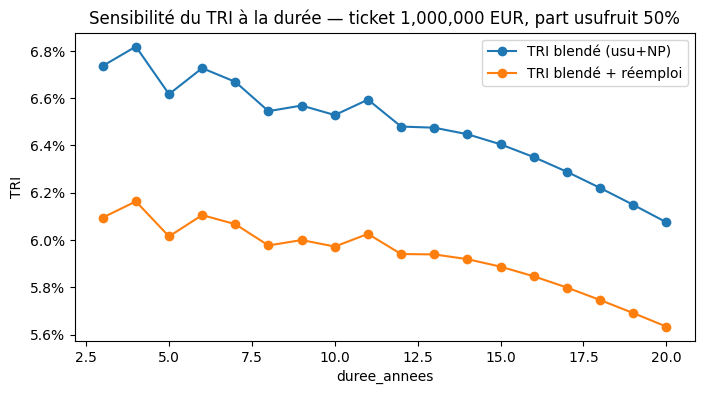

In [7]:
sens_rows = []
for d in grille.index:
    h = {**hyp, "duree_annees": int(d)}
    k_usu = get_usu_key(d, grille)
    k_np = 1 - k_usu
    cf = build_cashflows_usu_np(h, k_usu, k_np)
    sens_rows.append(
        {
            "duree_annees": int(d),
            "cle_usufruit": k_usu,
            "TRI blendé (usu+NP)": xirr(cf, "flux_blend"),
            "TRI blendé + réemploi": xirr(cf, "flux_blend_reemploi"),
        }
    )
sensibilite = pd.DataFrame(sens_rows)

ax = sensibilite.plot(
    x="duree_annees",
    y=["TRI blendé (usu+NP)", "TRI blendé + réemploi"],
    marker="o",
    title=f"Sensibilité du TRI à la durée — ticket {hyp['ticket_total']:,.0f} EUR, part usufruit {hyp['part_usufruit']:.0%}",
    figsize=(8, 4),
)
ax.set_ylabel("TRI")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
sensibilite
